# Online Retail II - DOI: 10.24432/C5CG6D

### 1. What this dataset is

A multi-year export from a UK online retailer. Each row is a **line item** on an invoice. The table captures products bought, quantities, prices, timestamps, and basic customer metadata. There is no single “row per customer” or “row per product” view. We must construct it.

#### 1.1 Canonical columns

| Column        | Type      | Typical role                                   | Notes that matter for modelling                              |
|:--------------|:----------|:-----------------------------------------------|:--------------------------------------------------------------|
| `InvoiceNo`   | string    | Transaction grouping key                        | Cancellation invoices often start with `C`.                   |
| `StockCode`   | string    | Product identifier                              | Product taxonomy is implicit, text `Description` is noisy.    |
| `Description` | string    | Human-readable product text                     | Typos, duplicates, subtle variants. Candidate for vectorising.|
| `Quantity`    | integer   | Items on the line                               | Can be negative on reversals. Zero appears in edge cases.     |
| `InvoiceDate` | datetime  | Event time                                      | Time zones and daylight savings must be handled consistently. |
| `Price`   | float     | Price per unit                                  | Zero or extreme values can occur. Check currency consistency. |
| `Customer ID`  | integer   | Customer identifier                             | Missing for some rows. Decide policy explicitly.              |
| `Country`     | string    | Customer location                               | High-cardinality if expanded. Watch the effect on distances.  |

### 2. Why it is non-trivial

1. **It is a ledger.** Clustering line items is rarely meaningful. We must decide what an **entity** is before analysis.
2. **Reality is messy.** Cancellations, negative quantities, zero prices, duplicates, missing `CustomerID`, and free-text descriptions introduce ambiguity.
3. **Time changes behaviour.** Seasonality, promotions, and drift make global aggregates misleading if time is ignored.
4. **Mixed data types.** Numeric spend and counts live beside countries and noisy text. Off-the-shelf Euclidean distance is fragile without preparation.

### 3. The first decision: unit of analysis

Different questions imply different entities and different feature engineering.

| Goal we care about                 | Entity to represent | Core evidence to aggregate                                      | Typical downstream method                |
|:-----------------------------------|:--------------------|:-----------------------------------------------------------------|:-----------------------------------------|
| Customer segmentation              | Customer            | RFM, basket size, product breadth, cancellation behaviour        | K-means or GMM after scaling or PCA       |
| Product families and substitutions | Product             | Co-purchase networks, seasonality profiles, price dynamics       | Community detection, hierarchical, HDBSCAN|
| Operational rhythms                | Invoice or time bin | Basket composition, value per invoice, intra-day or weekly shape | Time-series clustering, DTW-based methods |
| Anomaly and fraud signals          | Customer or invoice | Rare patterns, abnormal returns, atypical value or timing        | IsolationForest, LOF, One-Class SVM       |


### 4. Feature families that actually transfer to practice

We do not feed raw ledgers to algorithms. We **construct** a feature matrix where distances mean something.

#### 4.1 Behavioural features for customers

| Theme             | Examples that work in practice                                           | Caveats to document                                           |
|:------------------|:-------------------------------------------------------------------------|:--------------------------------------------------------------|
| Intensity         | Total spend, number of invoices, items per basket                        | Heavy tails suggest robust or quantile scaling                |
| Freshness         | Recency in days since last purchase                                      | Anchor to the dataset max date to avoid leakage               |
| Regularity        | Inter-purchase time variability, active months                           | Sensitive to sparse histories                                 |
| Breadth vs focus  | Distinct products count, Herfindahl index over product shares            | Product taxonomy resolution affects interpretation            |
| Returns behaviour | Cancellation rate, value of returns                                      | Separate from core spend to avoid contaminating centroids     |

#### 4.2 Representations for products

- Co-occurrence vectors over baskets, normalised to dampen popularity
- Seasonal signatures over week-of-year or month-of-year
- Price and discount dynamics, volatility measures

#### 4.3 Handling mixed types

- Numeric blocks: scale thoughtfully (Standard, Robust, or Quantile transformers)
- Categorical blocks: one-hot can dominate Euclidean distances if high-dimensional
- Text blocks: TF-IDF or embeddings with cosine similarity, not naive Euclidean


### 5. What we are trying to achieve here

1. **Construct auditable feature matrices** from transactional data for a chosen entity.
2. **Define similarity deliberately** so that near points are meaningfully similar in business terms.
3. **Explore latent structure** with clustering and dimensionality reduction without fooling ourselves.
4. **Validate and profile** segments with internal metrics, stability checks, and domain-level summaries.
5. **Translate findings into action**: segment playbooks, product taxonomy hints, anomaly watchlists.


### 6. The working approach we will follow

1. **Load and audit** the raw ledger with explicit typing and date handling.  
2. **Declare the unit of analysis** and the time window for the question at hand.  
3. **Clean with intent**: split cancellation analytics from core spend, remove duplicates, document exclusions.  
4. **Engineer features** that encode behaviour and composition, keeping provenance for every column.  
5. **Shape the geometry**: scale numerics, isolate sparse categoricals, choose metrics that fit representations.  
6. **Only then** apply clustering, embeddings, or anomaly scoring, followed by rigorous validation and profiling.


### 7. Key modelling constraint to remember

> Algorithms consume matrices, not ledgers. The quality of unsupervised results is determined less by the choice of algorithm and more by the **mapping from domain behaviour to feature space**. We will make that mapping explicit at every step.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
url = "https://github.com/jhlopesalves/data-science-notebooks/raw/refs/heads/main/Python/projects/online_retail_ii/data/online_retail_II.xlsx"

dtype_map = {
    "Invoice": "string",
    "StockCode": "string",
    "Description": "string",
    "Quantity": "Int64",
    "InvoiceDate": "string",
    "Price": "float64",
    "Customer ID": "Int64",
    "Country": "string",
}

retail_raw = pd.read_excel(url, dtype=dtype_map)

retail_raw["InvoiceDate"] = pd.to_datetime(
    retail_raw["InvoiceDate"], errors="coerce"
).dt.tz_localize("Europe/London")

In [5]:
print(retail_raw.shape)
retail_raw.info(memory_usage="deep")

(525461, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype                        
---  ------       --------------   -----                        
 0   Invoice      525461 non-null  string                       
 1   StockCode    525461 non-null  string                       
 2   Description  522533 non-null  string                       
 3   Quantity     525461 non-null  Int64                        
 4   InvoiceDate  525461 non-null  datetime64[ns, Europe/London]
 5   Price        525461 non-null  float64                      
 6   Customer ID  417534 non-null  Int64                        
 7   Country      525461 non-null  string                       
dtypes: Int64(2), datetime64[ns, Europe/London](1), float64(1), string(4)
memory usage: 140.9 MB


In [6]:
retail_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00+00:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00+00:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00+00:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00+00:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00+00:00,1.25,13085,United Kingdom


In [7]:
retail_raw.describe()

,Quantity,Price,Customer ID
count,525461.0,525461.000000,417534.0
mean,10.337667,4.688834,15360.645478
std,107.42411,146.126914,1680.811316
min,-9600.0,-53594.360000,12346.0
25%,1.0,1.250000,13983.0
50%,3.0,2.100000,15311.0
75%,10.0,4.210000,16799.0
max,19152.0,25111.090000,18287.0


In [8]:
missing_summary = retail_raw.isna().mean().sort_values(ascending=False).round(4)

retail_raw.shape, missing_summary

((525461, 8),
 Customer ID    0.2054
 Description    0.0056
 StockCode      0.0000
 Invoice        0.0000
 Quantity       0.0000
 InvoiceDate    0.0000
 Price          0.0000
 Country        0.0000
 dtype: float64)

In [9]:
for nums in ["Quantity", "Price"]:
    print(retail_raw[nums].agg(["min", "max"]))

min    -9600
max    19152
Name: Quantity, dtype: int64
min   -53594.36
max    25111.09
Name: Price, dtype: float64


### retail_txn (invoices, bills, cancelations, etc.) / retail_core (sales, prices, recency, etc.)

In [10]:
# Create a working copy of the raw ledger so transformations do not mutate original data
retail_txn = retail_raw.copy()

# Flag cancellation-like rows: invoice codes starting with 'C', negative quantities, or negative prices
retail_txn["is_cancellation"] = (
    # Check invoice text for cancellation marker (case-insensitive)
    retail_txn["Invoice"].str.upper().str.startswith("C")
    # Negative quantities typically indicate returns/reversals
    | (retail_txn["Quantity"] < 0)
    # Negative prices can also indicate corrections or refunds
    | (retail_txn["Price"] < 0)
)

# Compute signed line-level total (quantity * unit price) — preserves returns as negative spend
retail_txn["line_total"] = retail_txn["Quantity"] * retail_txn["Price"]

# Define a small set of StockCodes that represent non-product service lines to exclude from merchandising analysis
non_product_codes = {"POST", "D", "BANK CHARGES", "M", "S", "C2"}

# Mark service lines so we can separate operational fees from product sales (reduces noise in product-level features)
retail_txn["is_service_line"] = retail_txn["StockCode"].isin(non_product_codes)

# Capture absolute units to measure handled volume independent of sign (useful for returns rate denominators)
retail_txn["units_magnitude"] = retail_txn["Quantity"].abs()

# Capture absolute price magnitude to reason about pricing independent of sign corrections
retail_txn["price_magnitude"] = retail_txn["Price"].abs()

# Capture absolute line total to summarise monetary flow regardless of sign when needed
retail_txn["line_total_magnitude"] = retail_txn["line_total"].abs()

# Build a boolean mask selecting core sales: positive quantity/price, not cancellations, not service lines
mask_core = (
    # positive units imply a sale rather than a return
    (retail_txn["Quantity"] > 0)
    # positive price filters out negatives used for corrections/refunds
    & (retail_txn["Price"] > 0)
    # exclude explicit cancellations or reversal markers
    & (~retail_txn["is_cancellation"])
    # exclude service lines that are not product sales
    & (~retail_txn["is_service_line"])
)

# Define minimal columns required for a row to be considered a core sales line (ensures provenance)
essential_core = {"Invoice", "StockCode", "InvoiceDate", "Quantity", "Price"}

# Produce the cleaned core sales view by applying the mask and dropping rows missing essential fields
retail_core = retail_txn.loc[mask_core].dropna(subset=essential_core).copy()

In [11]:
retail_core

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,line_total,is_service_line,units_magnitude,price_magnitude,line_total_magnitude
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00+00:00,6.95,13085,United Kingdom,False,83.4,False,12,6.95,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00+00:00,6.75,13085,United Kingdom,False,81.0,False,12,6.75,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00+00:00,6.75,13085,United Kingdom,False,81.0,False,12,6.75,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00+00:00,2.10,13085,United Kingdom,False,100.8,False,48,2.10,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00+00:00,1.25,13085,United Kingdom,False,30.0,False,24,1.25,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00+00:00,2.95,17530,United Kingdom,False,5.9,False,2,2.95,5.9
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00+00:00,3.75,17530,United Kingdom,False,3.75,False,1,3.75,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00+00:00,3.75,17530,United Kingdom,False,3.75,False,1,3.75,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00+00:00,3.75,17530,United Kingdom,False,7.5,False,2,3.75,7.5


### Customer Features

In [12]:
# Filter to customers present in the core sales view (keeps features focused on valid customers)
core_known = retail_core[retail_core["Customer ID"].notna()].copy()

# Group customers and compute interpretable aggregates summarizing purchase behaviour
by_cust = core_known.groupby("Customer ID", as_index=False).agg(
    # number of distinct invoices -> frequency proxy
    num_invoices=("Invoice", "nunique"),
    # number of distinct SKUs -> product breadth
    num_products=("StockCode", "nunique"),
    # total spend across all core lines -> monetary value
    total_spend=("line_total", "sum"),
    # total units purchased (positive by construction in retail_core) -> volume
    total_units=("Quantity", "sum"),
    # timestamp of first purchase -> tenure start
    first_purchase=("InvoiceDate", "min"),
    # timestamp of last purchase -> recency reference
    last_purchase=("InvoiceDate", "max"),
)

# Capture timezone info for clarity (ensures tz-aware math remains consistent)
tz = core_known["InvoiceDate"].dt.tz

# Determine the latest transaction timestamp to anchor snapshot-based features
last_ts = core_known["InvoiceDate"].max()

# Use an end-of-day snapshot to avoid fractional-day recency artefacts
snapshot = last_ts.ceil("D")

# Recency in days from snapshot to last purchase (key R in RFM)
by_cust["recency_days"] = (snapshot - by_cust["last_purchase"]).dt.days

# Activity span in days between first and last purchase (relationship length); clip negatives
by_cust["activity_span_days"] = (
    by_cust["last_purchase"] - by_cust["first_purchase"]
).dt.days.clip(lower=0)

# Sales-weighted average price per unit to capture typical unit economics per customer
by_cust["avg_price_weighted"] = np.where(
    # guard: only compute when total_units > 0 to avoid division by zero
    by_cust["total_units"] > 0,
    # compute weighted average price
    by_cust["total_spend"] / by_cust["total_units"],
    # otherwise mark as NaN (unknown/undefined)
    np.nan,
)

# Select and copy the final customer_features table with clear, auditable columns
customer_features = by_cust[
    [
        "Customer ID",
        "num_invoices",
        "num_products",
        "total_spend",
        "total_units",
        "avg_price_weighted",
        "first_purchase",
        "last_purchase",
        "recency_days",
        "activity_span_days",
    ]
].copy()

# Sanity check: recency must be non-negative relative to the snapshot (fail-fast)
assert (
    customer_features["recency_days"].ge(0).all()
), "Recency must be ≥ 0 versus snapshot"

# Sanity check: every customer in this core view should have at least one invoice
assert (
    customer_features["num_invoices"].ge(1).all()
), "A customer in core should have ≥ 1 invoice"

In [13]:
customer_features

,Customer ID,num_invoices,num_products,total_spend,total_units,avg_price_weighted,first_purchase,last_purchase,recency_days,activity_span_days
0,12346,11,26,372.86,70,5.326571,2009-12-14 08:34:00+00:00,2010-06-28 13:53:00+01:00,164,196
1,12347,2,70,1323.32,828,1.598213,2010-10-31 14:20:00+00:00,2010-12-07 14:57:00+00:00,2,37
2,12348,1,19,221.16,372,0.594516,2010-09-27 14:59:00+01:00,2010-09-27 14:59:00+01:00,73,0
3,12349,2,89,2221.14,991,2.241312,2010-04-29 13:20:00+01:00,2010-10-28 08:23:00+01:00,42,181
4,12351,1,21,300.93,261,1.152989,2010-11-29 15:23:00+00:00,2010-11-29 15:23:00+00:00,10,0
...,...,...,...,...,...,...,...,...,...,...
4290,18283,6,158,641.77,336,1.910030,2010-02-19 17:16:00+00:00,2010-11-22 15:30:00+00:00,17,275
4291,18284,1,27,411.68,493,0.835051,2010-10-04 11:33:00+01:00,2010-10-04 11:33:00+01:00,66,0
4292,18285,1,11,377.0,144,2.618056,2010-02-17 10:24:00+00:00,2010-02-17 10:24:00+00:00,295,0
4293,18286,2,66,1246.43,607,2.053427,2009-12-16 10:45:00+00:00,2010-08-20 11:57:00+01:00,111,247


### Invoice Features

In [14]:
# Keep evidence literal by selecting transactions with a known customer ID from the raw ledger (avoids using cleaned-only view)
txn_known = retail_txn[retail_txn["Customer ID"].notna()].copy()

# Compute total returned units per customer by summing absolute negative-quantity lines (captures return volume regardless of sign)
returned_units = (
    txn_known.loc[txn_known["Quantity"] < 0]
    .groupby("Customer ID")["Quantity"]
    .apply(lambda s: s.abs().sum())
)

# Compute handled units per customer as the sum of absolute quantities (denominator representing total units processed)
handled_units = txn_known.groupby("Customer ID")["Quantity"].apply(
    lambda s: s.abs().sum()
)

# Derive a per-customer returns rate = returned_units / handled_units, filling NaN with 0 for customers with no returned units
returns_rate = (
    (returned_units / handled_units).fillna(0.0).rename("returns_rate").reset_index()
)

# Extract an invoice-level timestamp by taking the latest line timestamp for each invoice (anchors invoice-level features)
invoice_time = (
    retail_txn.groupby("Invoice", as_index=False)["InvoiceDate"]
    .max()
    .rename(columns={"InvoiceDate": "invoice_timestamp"})
)

# Aggregate signed monetary total and item counts per invoice; use absolute item counts for volume-related features
by_invoice = retail_txn.groupby("Invoice", as_index=False).agg(
    invoice_total_signed=("line_total", "sum"),
    items_count_abs=("Quantity", lambda x: np.abs(x).sum()),
    items_count_signed=("Quantity", "sum"),
    distinct_skus_all=("StockCode", "nunique"),
)

# Build a sales-only invoice grouping (exclude service lines) to get a cleaner measure of product breadth in baskets
by_invoice_sales = retail_txn.loc[~retail_txn["is_service_line"]].groupby(
    "Invoice", as_index=False
)

# Compute distinct SKUs per invoice considering only product sales (reduces noise from service/fee lines)
invoice_breadth = by_invoice_sales.agg(distinct_skus_sales=("StockCode", "nunique"))

# Merge invoice-level aggregates, breadth, and timestamp into a single invoice_features table (left joins preserve invoices)
invoice_features = by_invoice.merge(invoice_breadth, on="Invoice", how="left").merge(
    invoice_time, on="Invoice", how="left"
)

# Extract the invoice hour of day as a simple time-of-day feature (captures diurnal buying patterns)
invoice_features["invoice_hour"] = invoice_features["invoice_timestamp"].dt.hour

# Extract the invoice weekday as a simple seasonal feature (captures weekly cyclic behaviour; 0=Monday..6=Sunday)
invoice_features["invoice_weekday"] = invoice_features["invoice_timestamp"].dt.weekday

### Returns ratings 

In [15]:
# Merge per-customer returns rate into the customer features table using a left join to preserve all customers
customer_features = customer_features.merge(returns_rate, on="Customer ID", how="left")

# Fill missing returns_rate with 0.0 because absence of return records implies zero observed returns (avoids NaNs in downstream stats)
customer_features["returns_rate"] = customer_features["returns_rate"].fillna(0.0)

# Compute average spend per invoice as a size-normalised measure useful before clustering; guard against division by zero
customer_features["avg_spend_per_invoice"] = (
    customer_features["total_spend"] / customer_features["num_invoices"]
).replace([np.inf, -np.inf], np.nan)

# Compute average distinct SKUs per invoice to capture product breadth per purchase, again guarding against infinities
customer_features["avg_distinct_skus_per_invoice"] = (
    customer_features["num_products"] / customer_features["num_invoices"]
).replace([np.inf, -np.inf], np.nan)

In [16]:
invoice_features

,Invoice,invoice_total_signed,items_count_abs,items_count_signed,distinct_skus_all,distinct_skus_sales,invoice_timestamp,invoice_hour,invoice_weekday
0,489434,505.3,166,166,8,8.0,2009-12-01 07:45:00+00:00,7,1
1,489435,145.8,60,60,4,4.0,2009-12-01 07:46:00+00:00,7,1
2,489436,630.33,193,193,19,19.0,2009-12-01 09:06:00+00:00,9,1
3,489437,310.75,145,145,23,23.0,2009-12-01 09:08:00+00:00,9,1
4,489438,2286.24,826,826,17,17.0,2009-12-01 09:24:00+00:00,9,1
...,...,...,...,...,...,...,...,...,...
28811,C538121,-12.75,1,-1,1,1.0,2010-12-09 15:36:00+00:00,15,3
28812,C538122,-1.25,1,-1,1,1.0,2010-12-09 15:38:00+00:00,15,3
28813,C538123,-7.5,4,-4,3,3.0,2010-12-09 15:41:00+00:00,15,3
28814,C538124,-17.7,6,-6,3,2.0,2010-12-09 15:43:00+00:00,15,3


In [17]:
customer_features

,Customer ID,num_invoices,num_products,total_spend,total_units,avg_price_weighted,first_purchase,last_purchase,recency_days,activity_span_days,returns_rate,avg_spend_per_invoice,avg_distinct_skus_per_invoice
0,12346,11,26,372.86,70,5.326571,2009-12-14 08:34:00+00:00,2010-06-28 13:53:00+01:00,164,196,0.204545,33.896364,2.363636
1,12347,2,70,1323.32,828,1.598213,2010-10-31 14:20:00+00:00,2010-12-07 14:57:00+00:00,2,37,0.000000,661.66,35.000000
2,12348,1,19,221.16,372,0.594516,2010-09-27 14:59:00+01:00,2010-09-27 14:59:00+01:00,73,0,0.000000,221.16,19.000000
3,12349,2,89,2221.14,991,2.241312,2010-04-29 13:20:00+01:00,2010-10-28 08:23:00+01:00,42,181,0.005010,1110.57,44.500000
4,12351,1,21,300.93,261,1.152989,2010-11-29 15:23:00+00:00,2010-11-29 15:23:00+00:00,10,0,0.000000,300.93,21.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4290,18283,6,158,641.77,336,1.910030,2010-02-19 17:16:00+00:00,2010-11-22 15:30:00+00:00,17,275,0.000000,106.961667,26.333333
4291,18284,1,27,411.68,493,0.835051,2010-10-04 11:33:00+01:00,2010-10-04 11:33:00+01:00,66,0,0.002020,411.68,27.000000
4292,18285,1,11,377.0,144,2.618056,2010-02-17 10:24:00+00:00,2010-02-17 10:24:00+00:00,295,0,0.000000,377.0,11.000000
4293,18286,2,66,1246.43,607,2.053427,2009-12-16 10:45:00+00:00,2010-08-20 11:57:00+01:00,111,247,0.025641,623.215,33.000000


### Percentale triage

In [23]:
# Percentile triage: choose columns that capture size, frequency-normalised size, recency, and returns behaviour
cols = [
    "num_products",
    "total_spend",
    "avg_spend_per_invoice",
    "recency_days",
    "returns_rate",
]

# Build a concise percentile summary to inspect median, upper-tail and extreme-tail behaviour
percentile_triage = (
    # Limit to the selected columns so the summary focuses on relevant features only
    customer_features[cols]
    # Compute descriptive stats including the median (50%) and upper percentiles (90%, 99%) to characterise skew
    .describe(percentiles=[0.5, 0.9, 0.99])
    # Transpose so each feature is a row and rename percentile columns to compact, interpretable labels
    .T.rename(columns={"50%": "p50", "90%": "p90", "99%": "p99"})
)

# Compute ratio of extreme (99th) to typical (50th) to quantify heavy-tail concentration; avoid dividing by zero
percentile_triage["p99_over_p50"] = percentile_triage["p99"] / percentile_triage[
    "p50"
].where(percentile_triage["p50"] != 0, np.nan)

display(percentile_triage)

,count,mean,std,min,p50,p90,p99,max,p99_over_p50
num_products,4295.0,63.768335,85.737819,1.0,38.0,148.0,389.0,1738.0,10.236842
total_spend,4295.0,2020.464183,8809.178404,2.95,695.66,3752.58,19750.1738,349164.35,28.390555
avg_spend_per_invoice,4295.0,374.66199,481.364712,2.95,285.67,663.3606,1934.33098,11880.84,6.771208
recency_days,4295.0,90.077299,96.869005,0.0,51.0,253.6,367.0,373.0,7.196078
returns_rate,4295.0,0.014403,0.051175,0.0,0.0,0.02995,0.272374,0.733923,NaN


Capping extreme outliers from number of products to improve clustering is a defensible move here to winsorise it at, say, the 99.5th percentile for the X you cluster on, not for your human-readable tables.

In [29]:
cap_products = customer_features["num_products"].quantile(0.995)

#### “Money/time” with heavy right tails


* **log1p** (monotone compression):
  $$
  z = \log(1 + x)
  $$
  Preserves order, compresses ratios. Safe at zero.

#### “Proportion/rate” bounded in $[0,1]$ with many zeros


* **square root** (variance-stabilising near 0),
  $$
  z = \sqrt{x}
  $$

Also add a **binary flag** `has_returns` = 1 if `returns_rate>0`. 

In [30]:
# Keep original customer_features by making an explicit copy to preserve provenance
cf = customer_features.copy()

# Add transformed variants to the copy; transformations reduce skew and create useful signals for modelling
cf = cf.assign(
    # Log-transform total_spend with log1p to compress heavy tails while preserving zeros (stabilises variance)
    log_total_spend=lambda d: np.log1p(d["total_spend"]),
    # Log-transform avg_spend_per_invoice; fill missing with 0 before log1p to avoid NaNs from missing invoices
    log_avg_spend_per_invoice=lambda d: np.log1p(d["avg_spend_per_invoice"].fillna(0)),
    # Square-root transform of returns_rate after clipping to [0,1]; appropriate for proportion-like features (variance stabilisation)
    sqrt_returns_rate=lambda d: np.sqrt(np.clip(d["returns_rate"], 0, 1)),
    # Binary indicator for whether a customer has any observed returns; useful as a categorical/flag feature
    has_returns=lambda d: (d["returns_rate"] > 0).astype("int8"),
    num_products_normalized=lambda d: (d["num_products"].clip(upper=cap_products)),
)

In [28]:
cf

,Customer ID,num_invoices,num_products,total_spend,total_units,avg_price_weighted,first_purchase,last_purchase,recency_days,activity_span_days,returns_rate,avg_spend_per_invoice,avg_distinct_skus_per_invoice,log_total_spend,log_avg_spend_per_invoice,sqrt_returns_rate,has_returns,num_products_normalized
0,12346,11,26,372.86,70,5.326571,2009-12-14 08:34:00+00:00,2010-06-28 13:53:00+01:00,164,196,0.204545,33.896364,2.363636,5.923881,3.552383,0.452267,1,26.0
1,12347,2,70,1323.32,828,1.598213,2010-10-31 14:20:00+00:00,2010-12-07 14:57:00+00:00,2,37,0.000000,661.66,35.000000,7.188654,6.496262,0.000000,0,70.0
2,12348,1,19,221.16,372,0.594516,2010-09-27 14:59:00+01:00,2010-09-27 14:59:00+01:00,73,0,0.000000,221.16,19.000000,5.403398,5.403398,0.000000,0,19.0
3,12349,2,89,2221.14,991,2.241312,2010-04-29 13:20:00+01:00,2010-10-28 08:23:00+01:00,42,181,0.005010,1110.57,44.500000,7.706226,7.013529,0.070781,1,89.0
4,12351,1,21,300.93,261,1.152989,2010-11-29 15:23:00+00:00,2010-11-29 15:23:00+00:00,10,0,0.000000,300.93,21.000000,5.710195,5.710195,0.000000,0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4290,18283,6,158,641.77,336,1.910030,2010-02-19 17:16:00+00:00,2010-11-22 15:30:00+00:00,17,275,0.000000,106.961667,26.333333,6.465787,4.681776,0.000000,0,158.0
4291,18284,1,27,411.68,493,0.835051,2010-10-04 11:33:00+01:00,2010-10-04 11:33:00+01:00,66,0,0.002020,411.68,27.000000,6.022672,6.022672,0.044947,1,27.0
4292,18285,1,11,377.0,144,2.618056,2010-02-17 10:24:00+00:00,2010-02-17 10:24:00+00:00,295,0,0.000000,377.0,11.000000,5.934894,5.934894,0.000000,0,11.0
4293,18286,2,66,1246.43,607,2.053427,2009-12-16 10:45:00+00:00,2010-08-20 11:57:00+01:00,111,247,0.025641,623.215,33.000000,7.128841,6.436495,0.160128,1,66.0


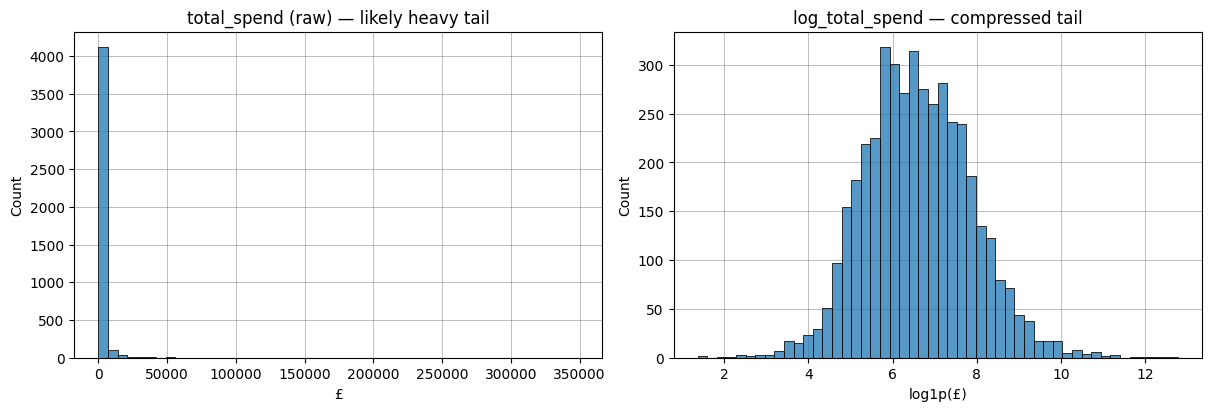

In [19]:
raw = customer_features["total_spend"].dropna()
logsp = cf["log_total_spend"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.histplot(raw, bins=50, ax=axes[0])
axes[0].set(title="total_spend (raw) — likely heavy tail", xlabel="£", ylabel="Count")
axes[0].grid(True, alpha=0.6, linewidth=0.6, color="grey")
axes[0].set_axisbelow(True)

sns.histplot(logsp, bins=50, ax=axes[1])
axes[1].set(
    title="log_total_spend — compressed tail", xlabel="log1p(£)", ylabel="Count"
)
axes[1].grid(True, alpha=0.6, linewidth=0.6, color="grey")
axes[1].set_axisbelow(True)

plt.show()

In [36]:
# select a shortlist of transformed and raw features for pairwise inspection (size, frequency, recency, returns, breadth)
shortlist_tx = [
    "log_total_spend",
    "log_avg_spend_per_invoice",
    "recency_days",
    "num_invoices",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
]

# drop rows with any missing values in the selected columns so correlation matrices compare the same observations
cf_s = cf[shortlist_tx].dropna()

# compute Spearman rank correlation (robust to heavy tails and monotone relationships)
spearman = cf_s.corr(method="spearman")

# compute Pearson correlation (measures linear association after the applied transforms)
pearson = cf_s.corr(method="pearson")

### Spearman: Rank-based (robust to remaining skew)

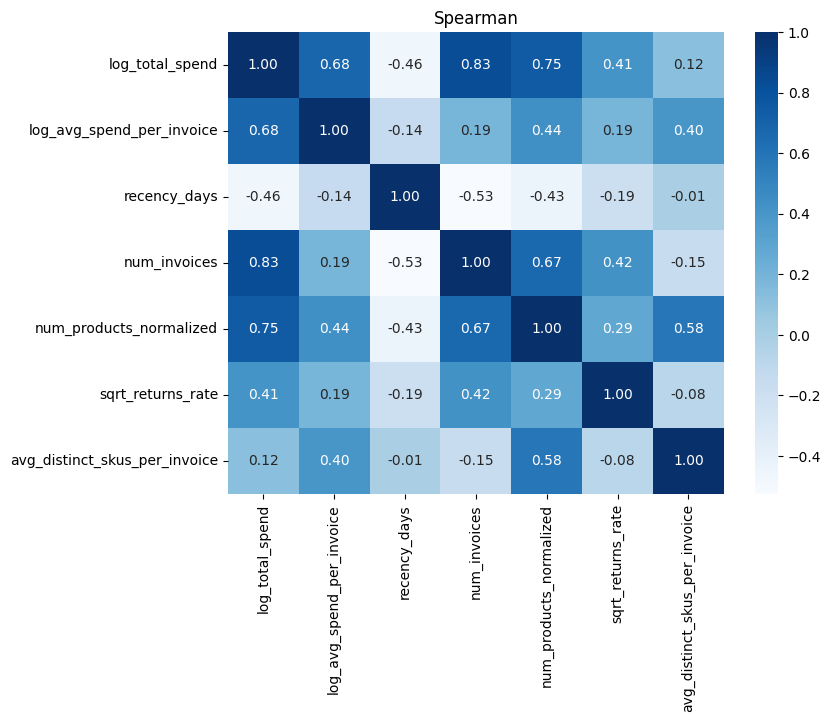

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(spearman, cmap="Blues", annot=True, fmt=".2f")
ax.set_title("Spearman")
plt.show()

### Pearson: Linear association after transforms


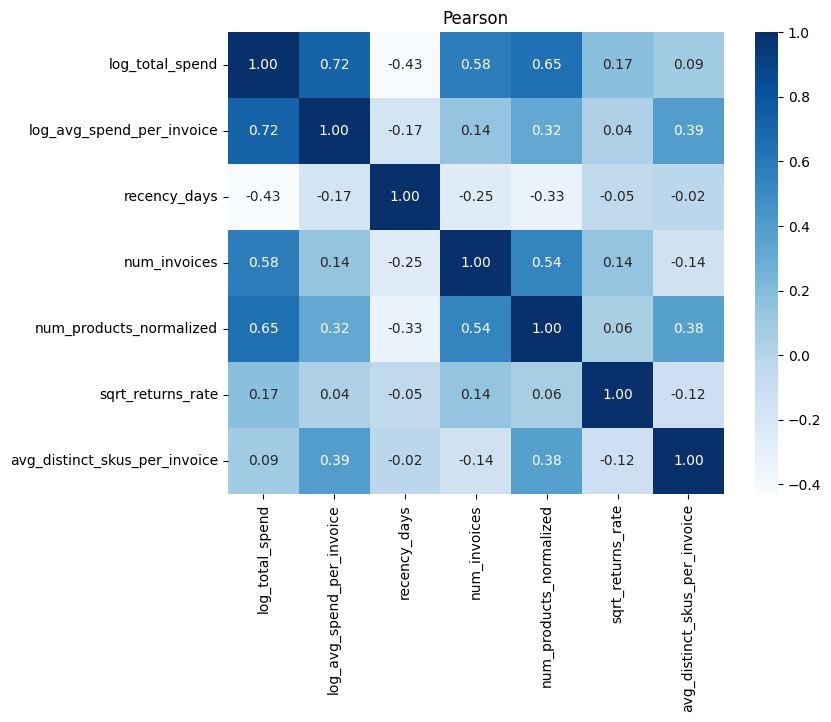

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pearson, cmap="Blues", annot=True, fmt=".2f")
ax.set_title("Pearson")
plt.show()

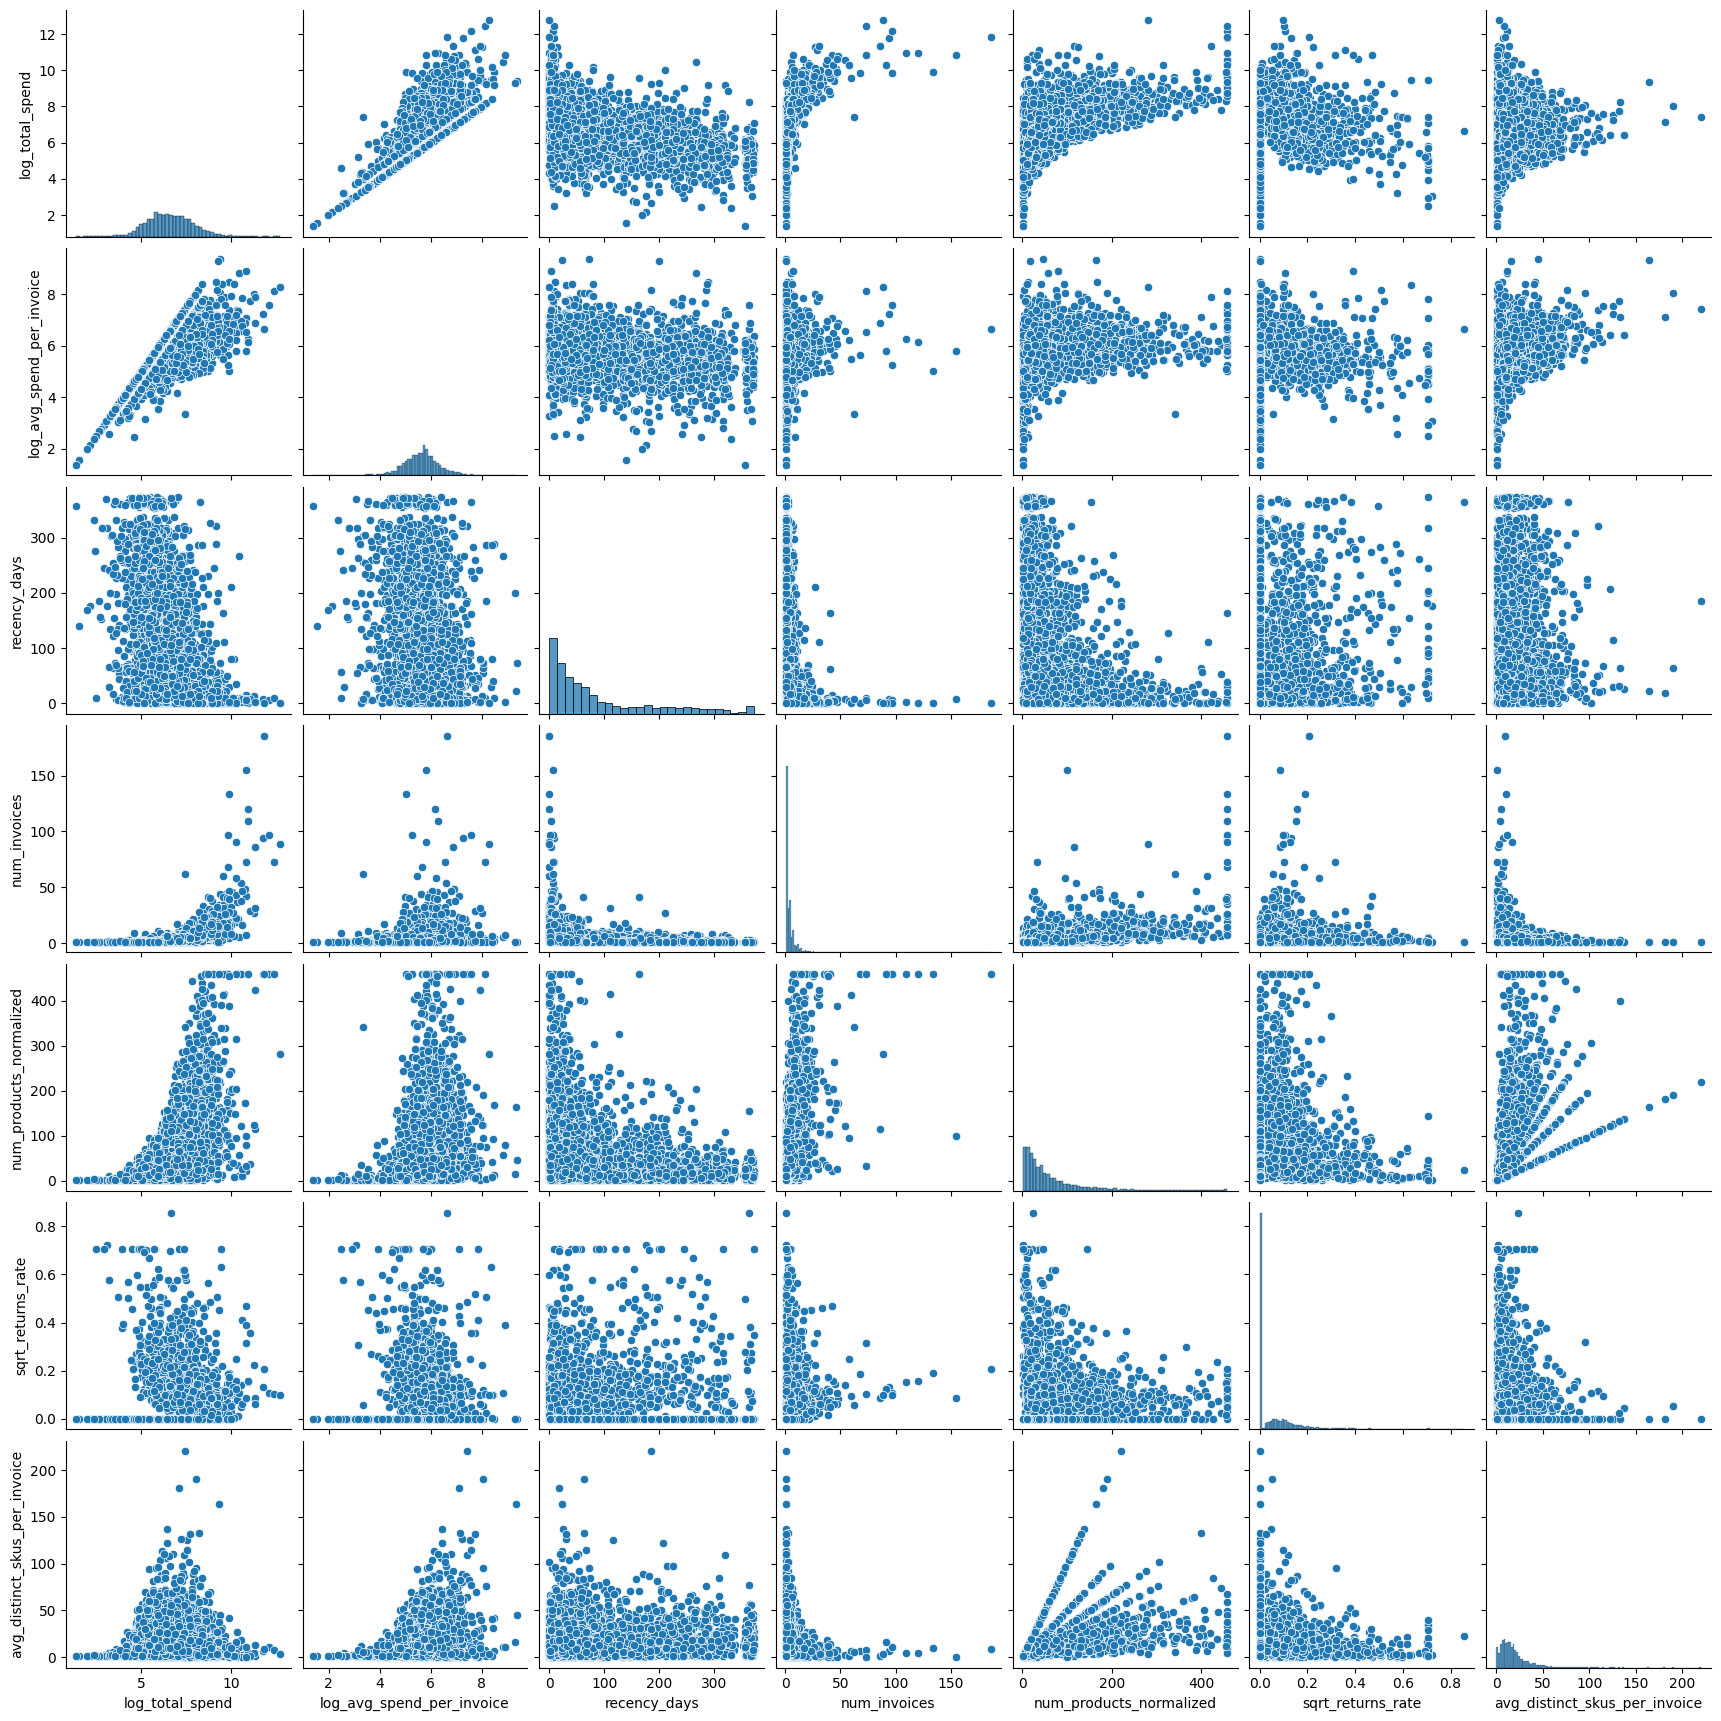

In [39]:
sns.pairplot(cf_s)
plt.show()

In [40]:
# Import StandardScaler to z-score features (centres to mean=0 and scales to unit variance)
from sklearn.preprocessing import StandardScaler

# Select modelling columns: size, tempo (recency in days), breadth, returns friction, and micro-diversity
cols = [
    "log_total_spend",
    "log_avg_spend_per_invoice",
    "recency_days",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
]

# Build a modelling dataframe from the transformed customer features and keep a copy to avoid mutating cf
M = cf[cols].copy()

# Impute any remaining missing values with the column median (robust to outliers; preserves central tendency)
M = M.fillna(M.median(numeric_only=True))

# Instantiate a StandardScaler to make features comparable for distance-based methods (PCA, KMeans, etc.)
scaler = StandardScaler()

# Fit the scaler on M and transform to produce the modelling matrix X in z-space
X = scaler.fit_transform(M)

# Compute column-wise means to verify centring (should be ~0) — numerical sanity check
X_mean = X.mean(axis=0).round(3)

# Compute column-wise standard deviations to verify scaling (should be ~1) — numerical sanity check
X_std = X.std(axis=0, ddof=0).round(3)

X_mean, X_std

(array([-0.,  0.,  0.,  0., -0.,  0.]), array([1., 1., 1., 1., 1., 1.]))

In [41]:
# import PCA class from scikit-learn (used to compute orthogonal components)
from sklearn.decomposition import PCA

# fit PCA to the already-scaled modelling matrix X, keeping 3 components for inspection
pca = PCA(n_components=3, random_state=42).fit(X)

# extract explained variance ratio per component (proportion of variance captured)
explained = pca.explained_variance_ratio_

# extract component loadings (PCs x features): direction cosines showing feature contributions
loadings = pca.components_

explained.round(3), np.round(loadings, 3)

(array([0.418, 0.199, 0.154]),
 array([[ 0.566,  0.489, -0.331,  0.493,  0.088,  0.284],
        [-0.219,  0.164,  0.331,  0.045, -0.622,  0.653],
        [-0.002,  0.287,  0.647, -0.1  ,  0.659,  0.233]]))

In [42]:
def pca_loadings_table(pca, feature_names, round_to=3):
    """
    Convert sklearn PCA outputs into a labelled DataFrame.

    Parameters
    ----------
    pca : sklearn.decomposition.PCA (already fit)
    feature_names : list[str]
        Names of the features in the exact order used to fit PCA.
    round_to : int
        Decimal places for display (doesn't affect the stored floats).

    Returns
    -------
    loadings_df : pd.DataFrame
        Rows = PCs (PC1..PCk). Columns = EVR, Cumulative, then feature loadings.
    tidy_long  : pd.DataFrame
        Long ("tidy") version with absolute loadings, sorted strongest-first
        within each PC (useful for quick inspection).
    """
    n = pca.n_components_
    pcs = [f"PC{i+1}" for i in range(n)]

    # Core loadings matrix, labelled
    loadings = pd.DataFrame(pca.components_, index=pcs, columns=feature_names)

    # Explained variance ratios
    evr = pd.Series(
        pca.explained_variance_ratio_, index=pcs, name="explained_var_ratio"
    )
    cum = evr.cumsum().rename("cumulative_explained")

    loadings_df = pd.concat([evr, cum, loadings], axis=1)

    # Tidy, sorted view by absolute weight (nice for summaries)
    tidy_long = (
        loadings.stack()
        .rename("loading")
        .reset_index()
        .rename(columns={"level_0": "PC", "level_1": "feature"})
    )
    tidy_long["abs_loading"] = tidy_long["loading"].abs()
    tidy_long = tidy_long.sort_values(
        ["PC", "abs_loading"], ascending=[True, False]
    ).reset_index(drop=True)

    return loadings_df, tidy_long

In [61]:
# Define the original feature names in the exact order they were used to fit PCA;
# the order is critical because PCA components align with this feature ordering.
feature_names = [
    "log_total_spend",
    "log_avg_spend_per_invoice",
    "recency_days",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
]

# Convert the fitted PCA into a labeled loadings dataframe and a tidy long view;
# this helps interpret how each original feature contributes to each principal component.
loadings_df, tidy = pca_loadings_table(pca, feature_names)

# Select the top 3 driving features for each principal component by absolute loading;
# large absolute loadings indicate strong influence on the component (direction sign shows correlation).
top3 = tidy.groupby("PC").head(3).loc[:, ["PC", "feature", "loading", "abs_loading"]]

print(loadings_df)

     explained_var_ratio  cumulative_explained  log_total_spend  \
PC1             0.418407              0.418407         0.565544   
PC2             0.198867              0.617274        -0.218756   
PC3             0.153644              0.770917        -0.002280   

     log_avg_spend_per_invoice  recency_days  num_products_normalized  \
PC1                   0.488556     -0.331073                 0.493246   
PC2                   0.164349      0.331273                 0.045068   
PC3                   0.287252      0.647155                -0.099637   

     sqrt_returns_rate  avg_distinct_skus_per_invoice  
PC1           0.088264                       0.284221  
PC2          -0.621563                       0.653470  
PC3           0.659201                       0.232806  


In [45]:
# Select only the loading coefficient columns for the chosen features from the loadings summary table
loadings_only = loadings_df.loc[:, feature_names]

# Transpose the loadings so rows represent features and columns represent principal components (easier inspection)
loadings_T = loadings_only.T.copy()

# Name the index to document that rows correspond to features
loadings_T.index.name = "feature"

# Name the columns to document that columns correspond to principal components
loadings_T.columns.name = "PC"

# Extract the explained variance ratio per principal component to quantify how much variance each PC captures
evr = loadings_df["explained_var_ratio"].rename_axis("PC")

# Convert the explained variance Series to a DataFrame for tidy presentation and potential joins
evr_df = pd.DataFrame(evr)

In [46]:
loadings_T

PC,PC1,PC2,PC3
feature,,,
log_total_spend,0.565544,-0.218756,-0.002280
log_avg_spend_per_invoice,0.488556,0.164349,0.287252
recency_days,-0.331073,0.331273,0.647155
num_products_normalized,0.493246,0.045068,-0.099637
sqrt_returns_rate,0.088264,-0.621563,0.659201
avg_distinct_skus_per_invoice,0.284221,0.653470,0.232806


In [47]:
from sklearn.cluster import KMeans

# Build the modelling DataFrame from transformed customer features and impute medians to avoid missing-value bias
M = cf[feature_names].copy().fillna(cf[feature_names].median(numeric_only=True))


# Fit a StandardScaler on M to z-score each feature (centres to mean=0, scales to unit variance so distances are meaningful)
scaler = StandardScaler().fit(M)

# Apply the fitted scaler to produce the modelling matrix X in z-space for distance-based methods
X = scaler.transform(M)

# Fit KMeans as a baseline clustering model (k=3 chosen for interpretability; n_init increased for stability)
km = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X)

# Extract cluster assignments for each customer (integer labels)
labels = km.labels_

# Build cluster profiles in transformed-but-human units (means per cluster) to aid business interpretation
profiles = (
    cf.assign(cluster=labels)
    .groupby("cluster", as_index=True)[feature_names]
    .mean()
    .sort_index()
)

# Build cluster profiles in z-space so feature magnitudes are directly comparable across columns (useful for radar/bar plots)
profiles_z = (
    pd.DataFrame(X, columns=feature_names)
    .assign(cluster=labels)
    .groupby("cluster")[feature_names]
    .mean()
    .sort_index()
)

# Compute cluster sizes (counts) to report how many customers belong to each segment — important for viability decisions
sizes = pd.Series(labels).value_counts().sort_index().rename("n_customers")

# Attach cluster sizes to both readable and z-scored profile tables for completeness of the segment summary
profiles = profiles.join(sizes)
profiles_z = profiles_z.join(sizes)

In [48]:
df = pd.DataFrame(cf, columns=feature_names)
retail_clust_read = df.copy()
retail_clust_read["cluster"] = labels

display(retail_clust_read)

,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice,cluster
0,5.923881,3.552383,164,26.0,0.452267,2.363636,0
1,7.188654,6.496262,2,70.0,0.000000,35.000000,2
2,5.403398,5.403398,73,19.0,0.000000,19.000000,1
3,7.706226,7.013529,42,89.0,0.070781,44.500000,2
4,5.710195,5.710195,10,21.0,0.000000,21.000000,1
...,...,...,...,...,...,...,...
4290,6.465787,4.681776,17,158.0,0.000000,26.333333,1
4291,6.022672,6.022672,66,27.0,0.044947,27.000000,1
4292,5.934894,5.934894,295,11.0,0.000000,11.000000,0
4293,7.128841,6.436495,111,66.0,0.160128,33.000000,2


In [49]:
df = pd.DataFrame(X, columns=feature_names)
retail_clust_z = df.copy()
retail_clust_z["cluster"] = labels

display(retail_clust_z)

,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice,cluster
0,-0.534240,-2.813833,0.763209,-0.504608,3.745044,-0.983572,0
1,0.455855,1.168075,-0.909347,0.105662,-0.542725,0.983482,2
2,-0.941687,-0.310139,-0.176313,-0.601697,-0.542725,0.019133,1
3,0.861022,1.867732,-0.496370,0.369188,0.128327,1.556065,2
4,-0.701519,0.104836,-0.826752,-0.573957,-0.542725,0.139676,1
...,...,...,...,...,...,...,...
4290,-0.110023,-1.286209,-0.754481,1.326203,-0.542725,0.461126,1
4291,-0.456904,0.527495,-0.248584,-0.490738,-0.116603,0.501307,1
4292,-0.525619,0.408765,2.115708,-0.712655,-0.542725,-0.463042,0
4293,0.409031,1.087233,0.216015,0.050183,0.975388,0.862938,2


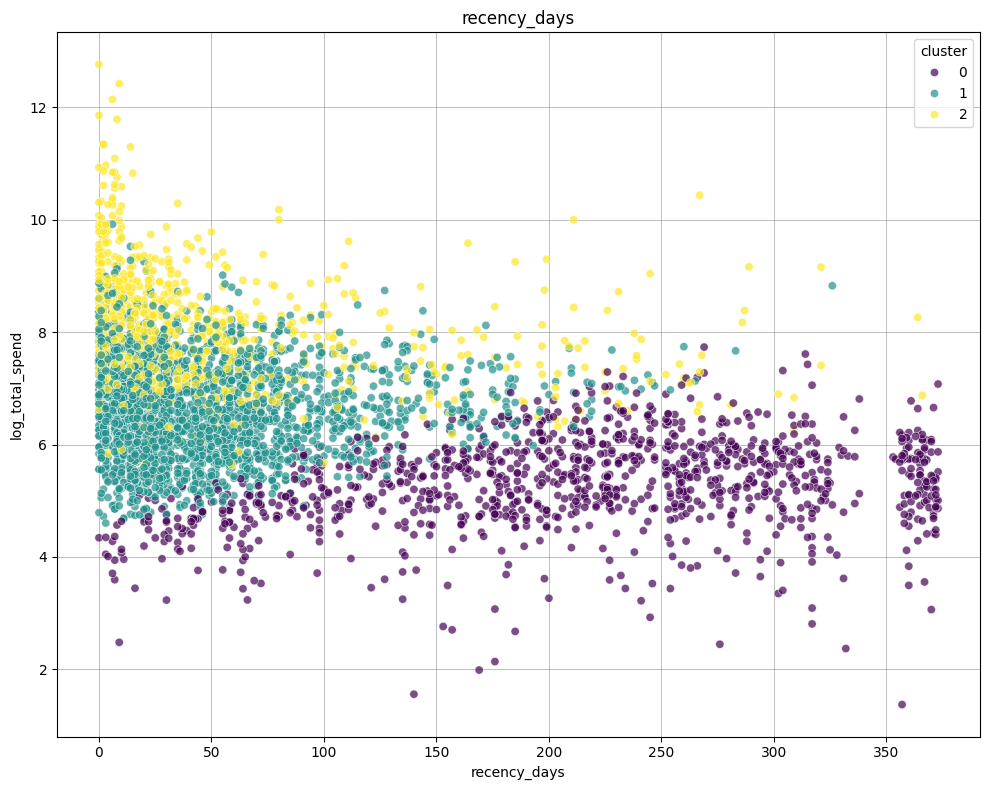

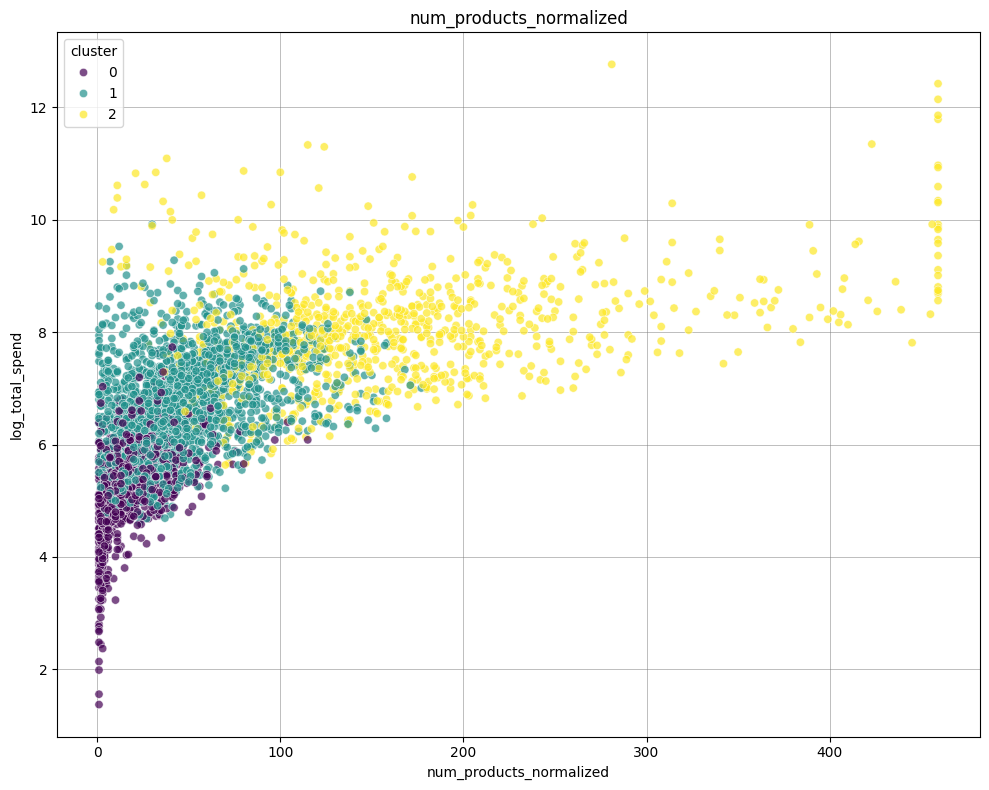

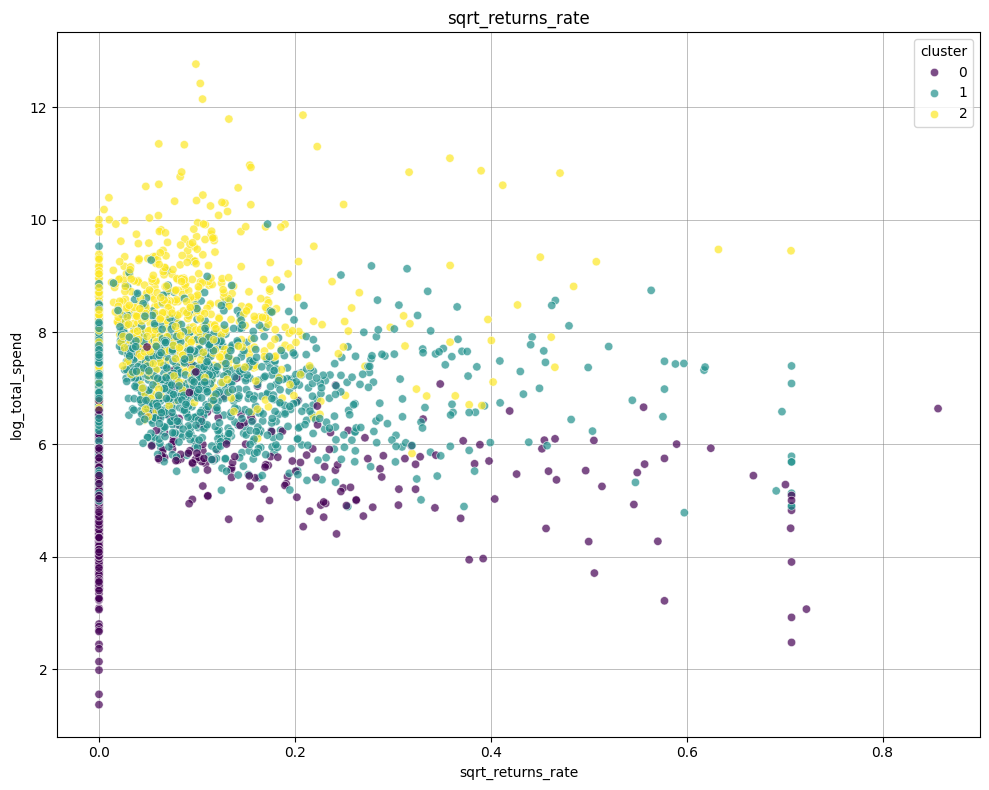

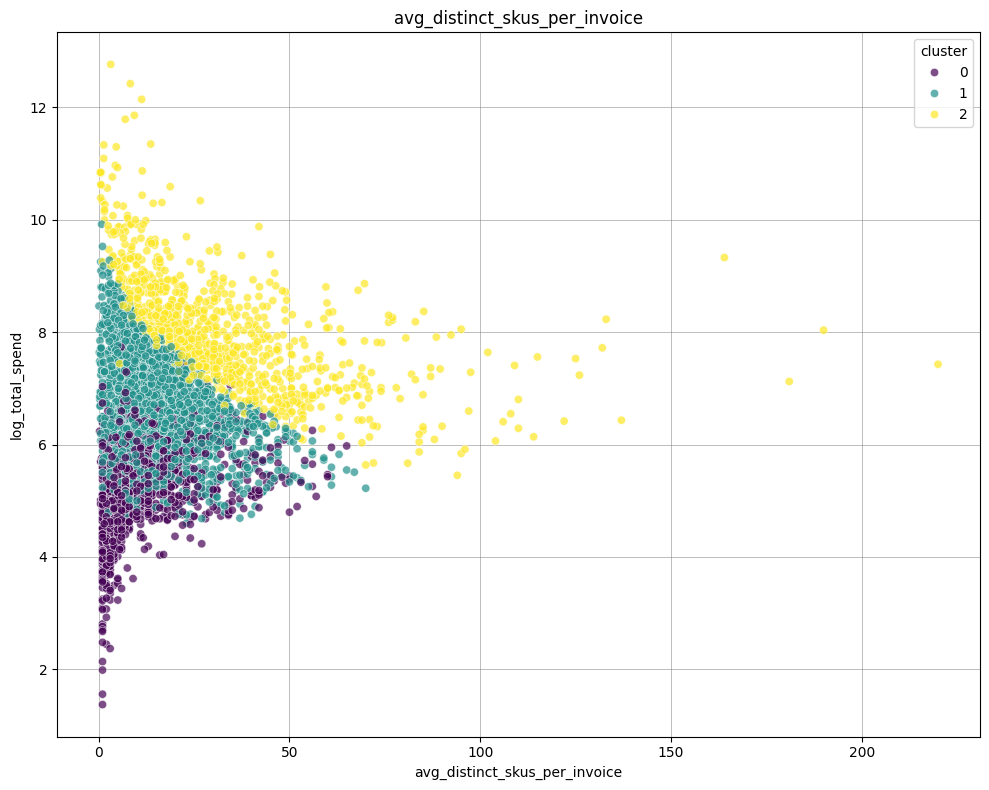

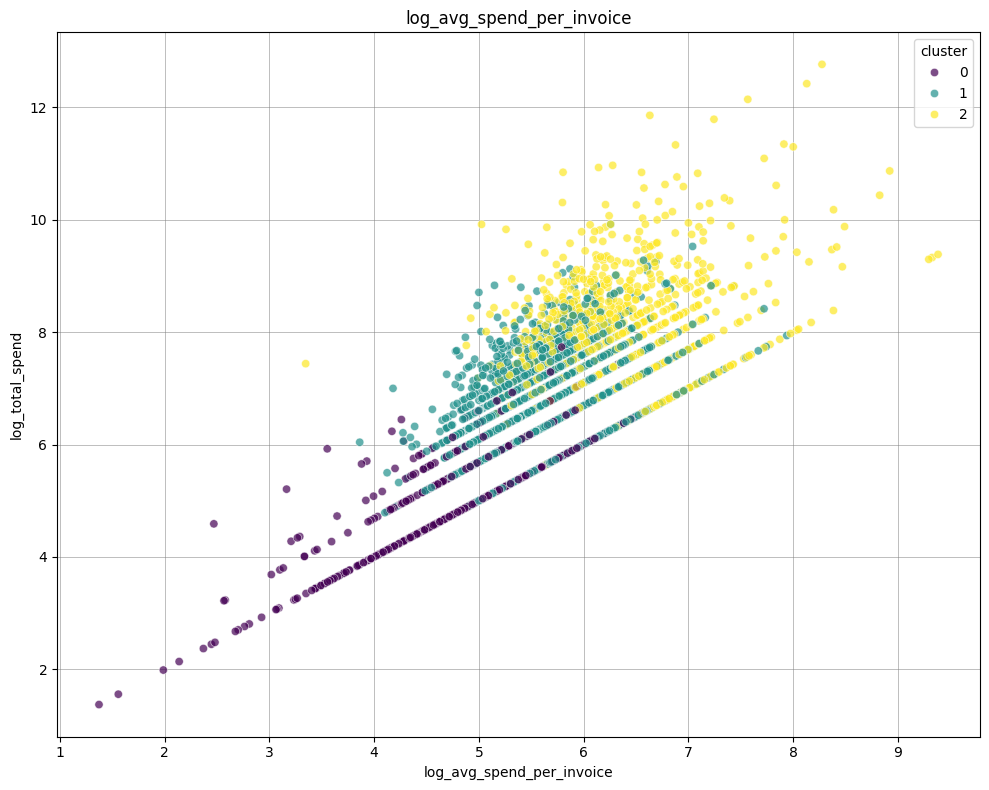

In [51]:
features = [
    "recency_days",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
    "log_avg_spend_per_invoice",
]

for feature in features:
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(
        data=retail_clust_read,
        x=feature,
        y="log_total_spend",
        hue="cluster",
        palette="viridis",
        alpha=0.7,  # Add transparency to handle overplotting
    )

    ax.set(
        title=feature,
    )
    ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
    ax.set_axisbelow(True)  # Ensure grid is behind the points

    plt.tight_layout()
    plt.show()

### Profiles in interpretable units (using transformed-but-human features)

In [52]:
profiles

,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice,n_customers
cluster,,,,,,,
0,5.29916,5.048713,214.006475,17.289547,0.041356,13.261074,1081
1,6.652618,5.631841,48.441202,44.557491,0.059633,15.653943,2296
2,8.029847,6.322474,48.278867,160.060959,0.069986,32.641534,918


### Profiles in z-scores (comparable across features)

In [53]:
profiles_z_ordered = profiles_z.loc[:, feature_names].copy()
profiles_z_ordered

,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice
cluster,,,,,,
0,-1.023287,-0.789889,1.279497,-0.625420,-0.150649,-0.326763
1,0.036233,-0.001146,-0.429869,-0.247220,0.022633,-0.182540
2,1.114360,0.933009,-0.431545,1.354788,0.120790,0.841333


In [55]:
profiles_z_T = profiles_z[feature_names].T  # rows = features, cols = clusters
display(profiles_z_T)

cluster,0,1,2
log_total_spend,-1.023287,0.036233,1.114360
log_avg_spend_per_invoice,-0.789889,-0.001146,0.933009
recency_days,1.279497,-0.429869,-0.431545
num_products_normalized,-0.625420,-0.247220,1.354788
sqrt_returns_rate,-0.150649,0.022633,0.120790
avg_distinct_skus_per_invoice,-0.326763,-0.182540,0.841333


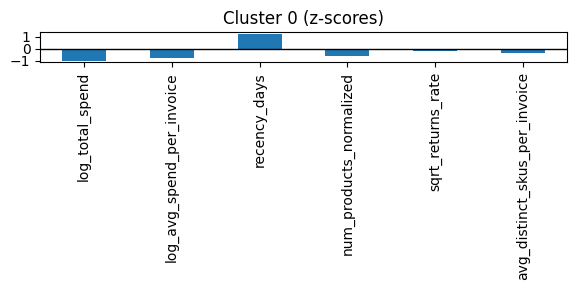

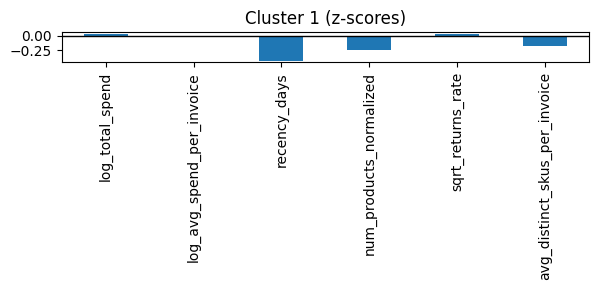

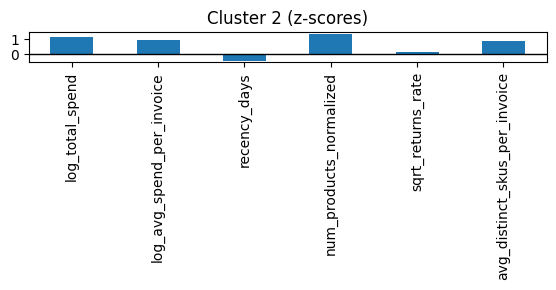

In [56]:
for k in profiles_z.index:
    ax = profiles_z.loc[k, feature_names].plot(
        kind="bar", figsize=(6, 3), title=f"Cluster {k} (z-scores)"
    )
    ax.axhline(0, linewidth=1, color="black")
    plt.tight_layout()
    plt.show()

In [57]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X, labels, metric="euclidean")
sil

0.22954141510990786

In [58]:
def run_k(k):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    return km.labels_, silhouette_score(X, km.labels_)


for k in [2, 3, 4, 5]:
    lab, s = run_k(k)
    print(k, round(s, 3))

2 0.244
3 0.23
4 0.243
5 0.253


In [59]:
from sklearn.metrics import adjusted_rand_score


def labels_for(seed):
    return KMeans(n_clusters=3, n_init=20, random_state=seed).fit(X).labels_


L1, L2, L3 = labels_for(1), labels_for(2), labels_for(3)
ari12 = adjusted_rand_score(L1, L2)
ari23 = adjusted_rand_score(L2, L3)
ari13 = adjusted_rand_score(L1, L3)
ari12, ari23, ari13

(0.9917702193953956, 0.9826964927865081, 0.9805287907634307)

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# X already built from: log_total_spend, log_avg_spend_per_invoice, recency_days,
# num_products_normalized (winsorised), sqrt_returns_rate, avg_distinct_skus_per_invoice

# 1) Fit k=4 with a stable n_init
km4 = KMeans(n_clusters=4, n_init=30, random_state=42).fit(X)
lab4 = km4.labels_

# 2) Quality
sil4 = silhouette_score(X, lab4)


# 3) Stability (three seeds)
def labels_k4(seed):
    return KMeans(n_clusters=4, n_init=30, random_state=seed).fit(X).labels_


L1, L2, L3 = labels_k4(1), labels_k4(2), labels_k4(3)
ari = (
    adjusted_rand_score(L1, L2)
    + adjusted_rand_score(L2, L3)
    + adjusted_rand_score(L1, L3)
) / 3

# 4) Sizes
sizes4 = pd.Series(lab4).value_counts(normalize=True).sort_index()

# 5) Profiles (z-space for comparability)
cols = [
    "log_total_spend",
    "log_avg_spend_per_invoice",
    "recency_days",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
]
profiles4_z = (
    pd.DataFrame(X, columns=cols)
    .assign(cluster=lab4)
    .groupby("cluster")[cols]
    .mean()
    .round(2)
)



(0.24324887842621265,
 0.9668134623230964,
 0    0.487776
 1    0.204191
 2    0.227474
 3    0.080559
 Name: proportion, dtype: float64,
          log_total_spend  log_avg_spend_per_invoice  recency_days  \
 cluster                                                             
 0                   0.01                       0.00         -0.44   
 1                   1.12                       0.92         -0.44   
 2                  -1.03                      -0.78          1.31   
 3                   0.01                      -0.11          0.11   
 
          num_products_normalized  sqrt_returns_rate  \
 cluster                                               
 0                          -0.24              -0.25   
 1                           1.41               0.03   
 2                          -0.62              -0.43   
 3                          -0.34               2.63   
 
          avg_distinct_skus_per_invoice  
 cluster                                 
 0                

In [66]:
sil4

0.24324887842621265

In [67]:
ari

0.9668134623230964

In [68]:
sizes4

0    0.487776
1    0.204191
2    0.227474
3    0.080559
Name: proportion, dtype: float64

In [69]:
profiles4_z

,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice
cluster,,,,,,
0,0.01,0.00,-0.44,-0.24,-0.25,-0.14
1,1.12,0.92,-0.44,1.41,0.03,0.85
2,-1.03,-0.78,1.31,-0.62,-0.43,-0.32
3,0.01,-0.11,0.11,-0.34,2.63,-0.42


In [70]:
df = pd.DataFrame(cf, columns=feature_names)
retail_clust_4 = df.copy()
retail_clust_4["cluster"] = lab4

display(retail_clust_4)

,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice,cluster
0,5.923881,3.552383,164,26.0,0.452267,2.363636,3
1,7.188654,6.496262,2,70.0,0.000000,35.000000,1
2,5.403398,5.403398,73,19.0,0.000000,19.000000,0
3,7.706226,7.013529,42,89.0,0.070781,44.500000,1
4,5.710195,5.710195,10,21.0,0.000000,21.000000,0
...,...,...,...,...,...,...,...
4290,6.465787,4.681776,17,158.0,0.000000,26.333333,0
4291,6.022672,6.022672,66,27.0,0.044947,27.000000,0
4292,5.934894,5.934894,295,11.0,0.000000,11.000000,2
4293,7.128841,6.436495,111,66.0,0.160128,33.000000,1


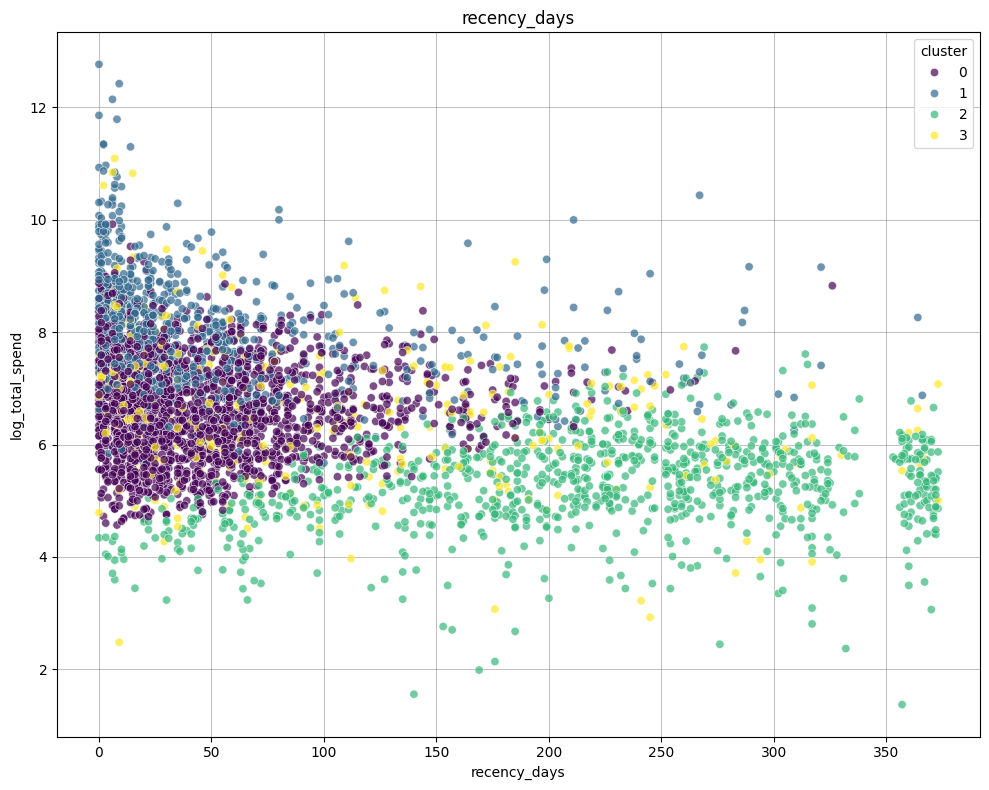

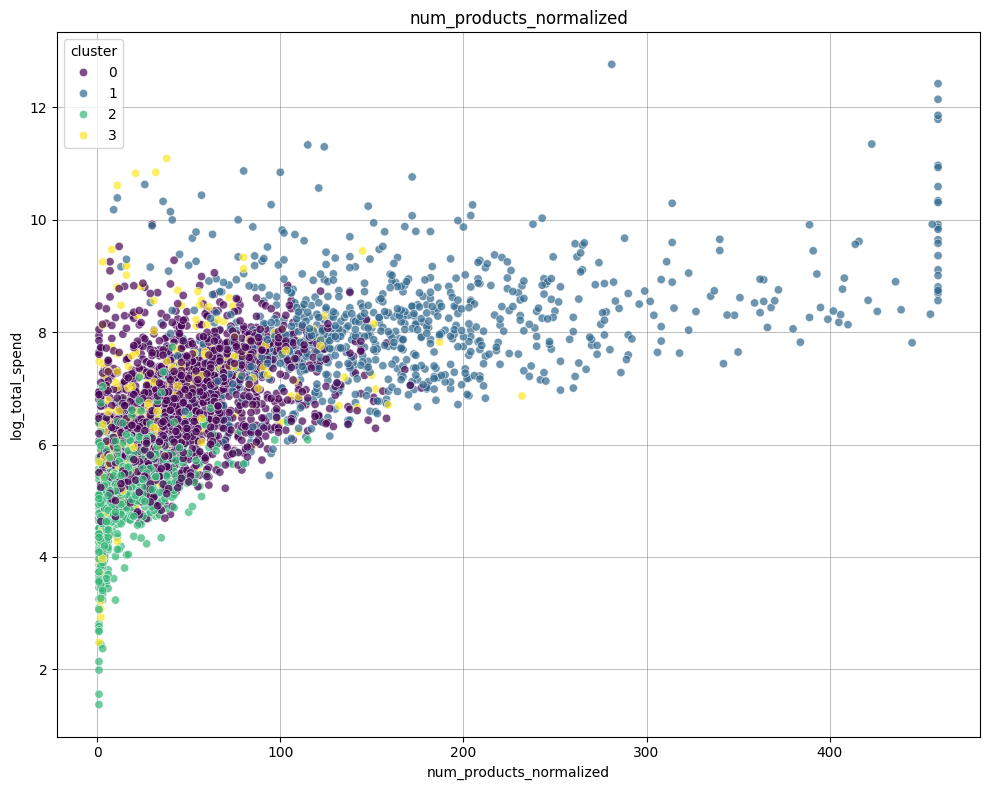

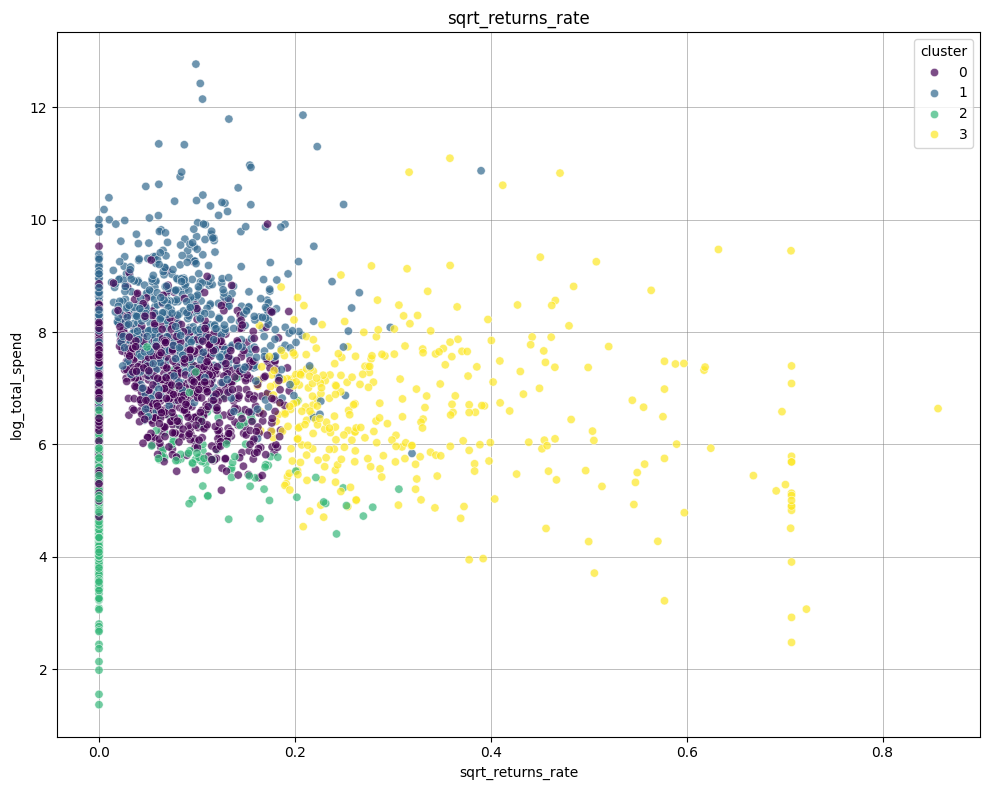

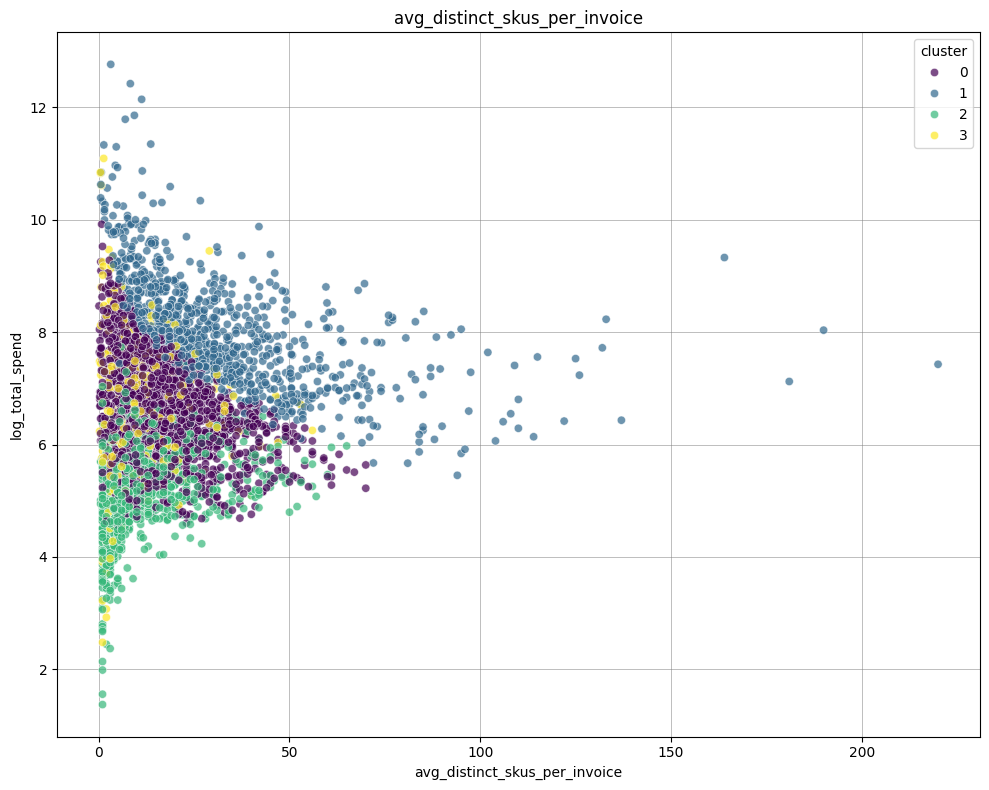

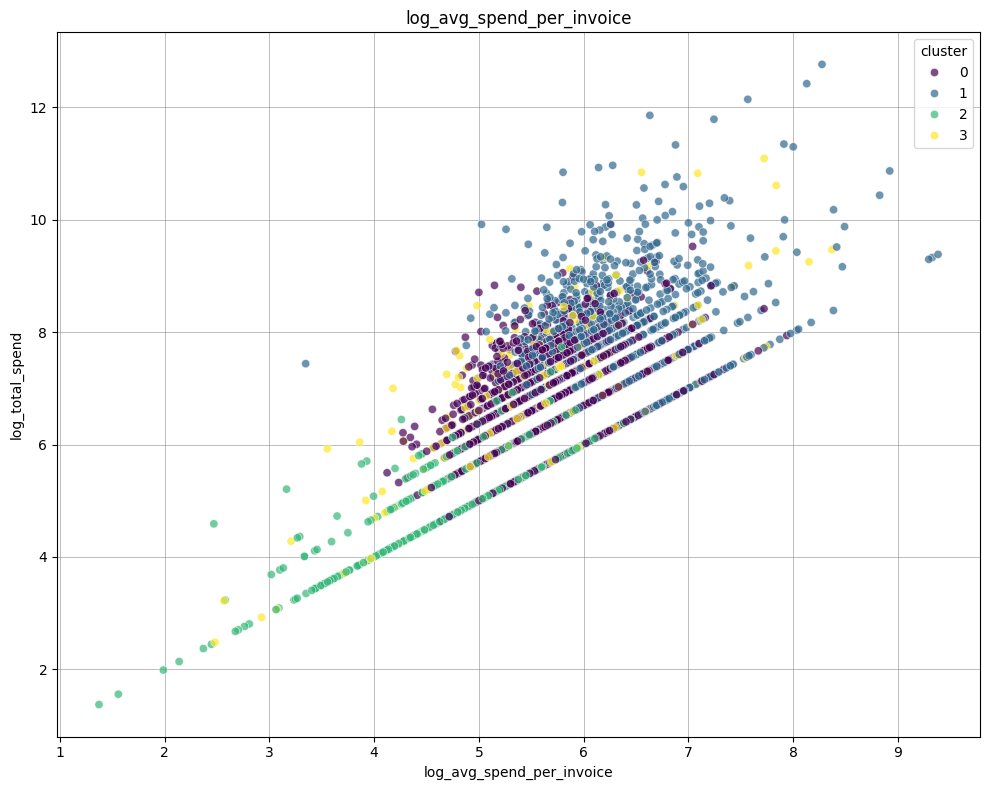

In [71]:
features = [
    "recency_days",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
    "log_avg_spend_per_invoice",
]

for feature in features:
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(
        data=retail_clust_4,
        x=feature,
        y="log_total_spend",
        hue="cluster",
        palette="viridis",
        alpha=0.7,  # Add transparency to handle overplotting
    )

    ax.set(
        title=feature,
    )
    ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
    ax.set_axisbelow(True)  # Ensure grid is behind the points

    plt.tight_layout()
    plt.show()

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.cluster import KMeans

# columns
cols = [
    "log_total_spend",
    "log_avg_spend_per_invoice",
    "recency_days",
    "num_products",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
]


# pure functions
def add_transforms(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_total_spend"] = np.log1p(out["total_spend"])
    out["log_avg_spend_per_invoice"] = np.log1p(out["avg_spend_per_invoice"].fillna(0))
    out["sqrt_returns_rate"] = np.sqrt(np.clip(out["returns_rate"], 0, 1))
    out["avg_distinct_skus_per_invoice"] = out[
        "avg_distinct_skus_per_invoice"
    ]  # already computed upstream
    out["num_products"] = out["num_products"]  # original; cap later
    return out


def cap_num_products(X: np.ndarray, cap: float) -> np.ndarray:
    X = X.copy()
    j = cols.index("num_products")
    X[:, j] = np.minimum(X[:, j], cap)
    return X


cap = customer_features["num_products"].quantile(0.995)

pipe = Pipeline(
    steps=[
        (
            "featurise",
            FunctionTransformer(
                add_transforms, validate=False, feature_names_out="one-to-one"
            ),
        ),
        (
            "select",
            FunctionTransformer(
                lambda d: d[cols], validate=False, feature_names_out="one-to-one"
            ),
        ),
        (
            "impute",
            FunctionTransformer(
                lambda d: d.fillna(d.median(numeric_only=True)),
                validate=False,
                feature_names_out="one-to-one",
            ),
        ),
        (
            "cap",
            FunctionTransformer(
                lambda d: pd.DataFrame(cap_num_products(d.values, cap), columns=cols),
                accept_sparse=False,
                feature_names_out="one-to-one",
            ),
        ),
        ("scale", StandardScaler()),
        ("kmeans", KMeans(n_clusters=4, n_init=20, random_state=42)),
    ]
)

In [73]:
names_k4 = {
    0: "Recent - focused - mid-spend",
    1: "Recent - broad - high-spend",
    2: "Dormant - light - narrow",
    3: "Recent - returns-heavy",
}
segment = pd.Series(lab4, name="cluster").map(names_k4)
segment.value_counts()

cluster
Recent - focused - mid-spend    2095
Dormant - light - narrow         977
Recent - broad - high-spend      877
Recent - returns-heavy           346
Name: count, dtype: int64

In [76]:
cols = [
    "log_total_spend",
    "log_avg_spend_per_invoice",
    "recency_days",
    "num_products_normalized",
    "sqrt_returns_rate",
    "avg_distinct_skus_per_invoice",
]

profiles4 = cf.assign(cluster=lab4).groupby("cluster")[cols].mean().round(2)
z4 = (
    pd.DataFrame(X, columns=cols)
    .assign(cluster=lab4)
    .groupby("cluster")[cols]
    .mean()
    .round(2)
)

sizes4 = pd.Series(lab4).value_counts().sort_index().rename("n_customers")
profiles4 = profiles4.join(sizes4)
z4 = z4.join(sizes4)

print("\nReadable profile table: ")
display(profiles4)
print("\nZ-scores profile table: ")
display(z4)


Readable profile table: 


,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice,n_customers
cluster,,,,,,,
0,6.62,5.63,47.13,44.78,0.03,16.35,2095
1,8.04,6.31,47.05,164.10,0.06,32.83,877
2,5.29,5.05,217.17,17.41,0.01,13.45,977
3,6.63,5.55,100.32,38.15,0.33,11.70,346



Z-scores profile table: 


,log_total_spend,log_avg_spend_per_invoice,recency_days,num_products_normalized,sqrt_returns_rate,avg_distinct_skus_per_invoice,n_customers
cluster,,,,,,,
0,0.01,0.00,-0.44,-0.24,-0.25,-0.14,2095
1,1.12,0.92,-0.44,1.41,0.03,0.85,877
2,-1.03,-0.78,1.31,-0.62,-0.43,-0.32,977
3,0.01,-0.11,0.11,-0.34,2.63,-0.42,346
